In [201]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [202]:
df = pd.read_csv("/content/insurance.csv")

In [203]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [204]:
df.shape

(1338, 7)

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [206]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [207]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [208]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

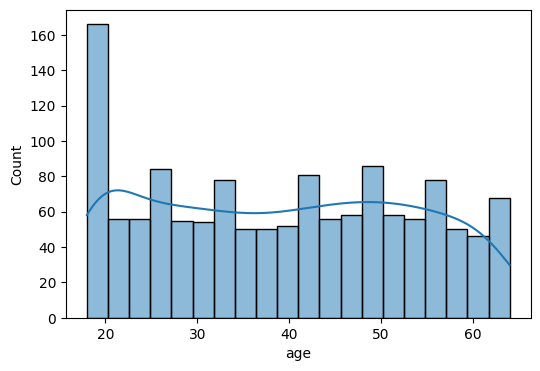

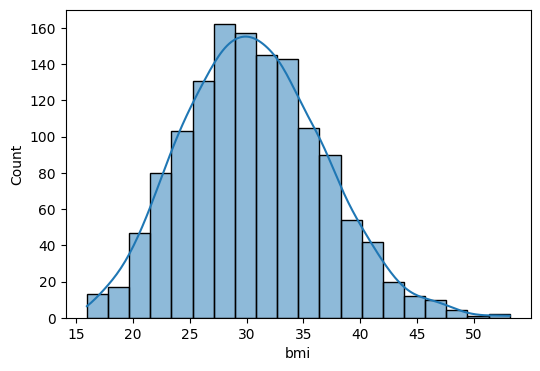

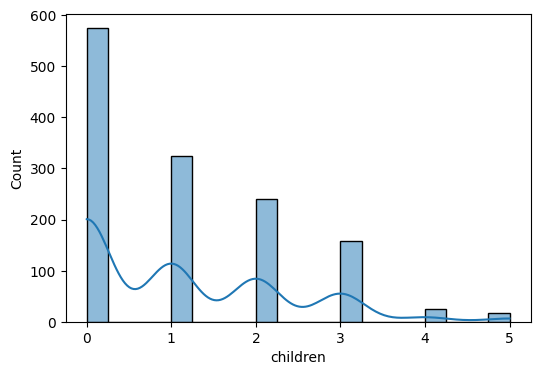

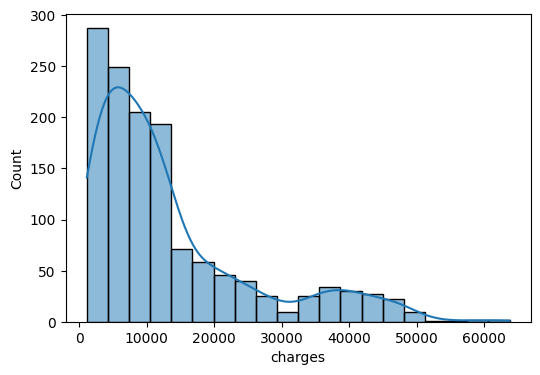

In [209]:
from matplotlib import axes
numeric_columns = ['age', 'bmi', 'children','charges']
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde = True,bins = 20)
  plt.show()

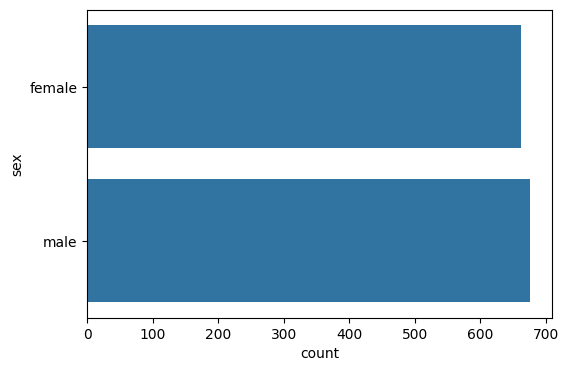

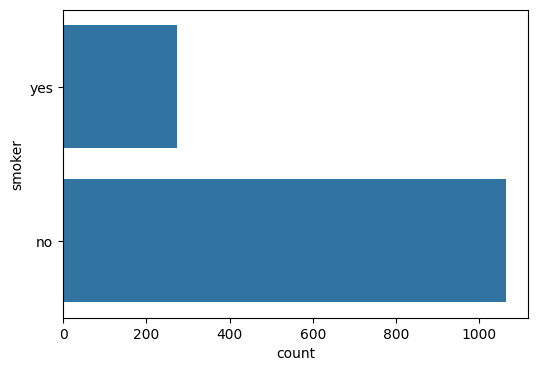

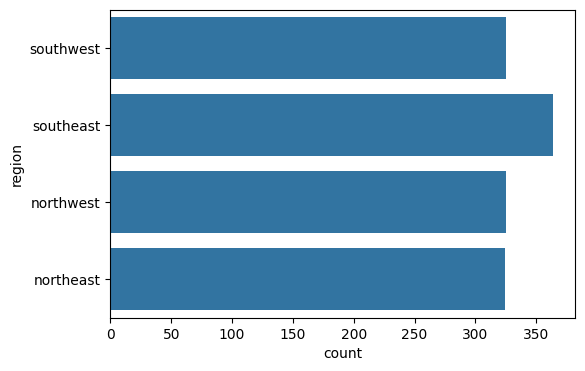

In [210]:
non_numeric_plots = ['sex','smoker','region']
for col in non_numeric_plots:
  plt.figure(figsize=(6,4))
  sns.countplot(df[col])

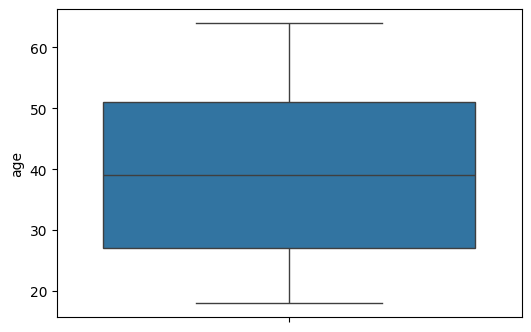

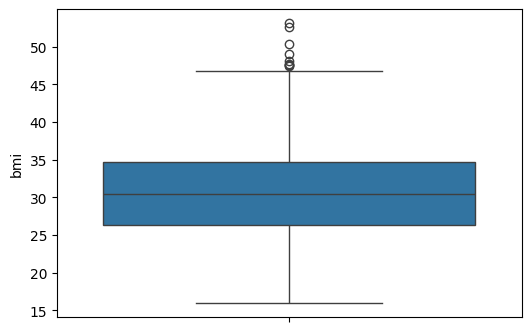

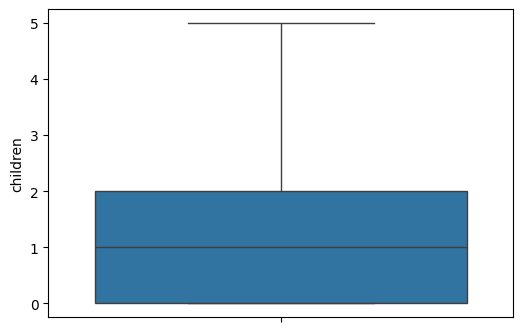

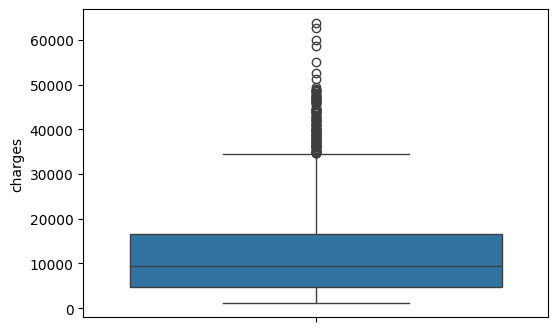

In [211]:
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[col])

<Axes: >

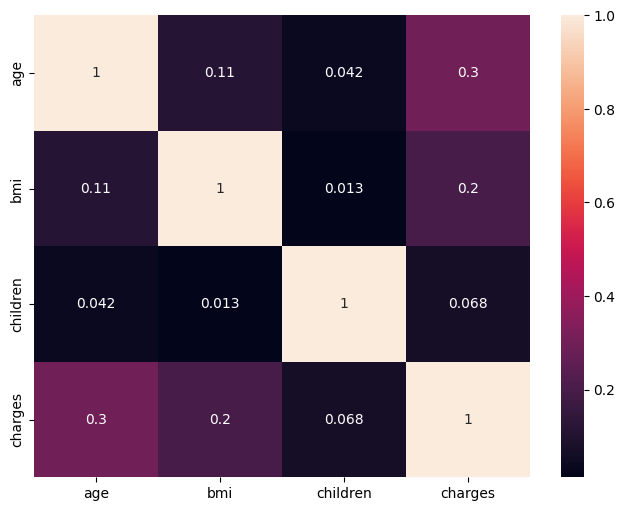

In [212]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# **Data Clearning and Preprocessing**

In [213]:
df_clearned = df.copy()

In [214]:
df_clearned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [215]:
df_clearned.drop_duplicates(inplace=True)

In [216]:
df_clearned.shape

(1337, 7)

In [217]:
df_clearned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [218]:
df_clearned['sex'].value_counts()

,count
sex,
male,675
female,662


In [219]:
df_clearned['sex']=df_clearned['sex'].map({"male":0,"female":1})

In [220]:
df_clearned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [221]:
df_clearned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [222]:
df_clearned['smoker']=df['smoker'].map({'no':0,'yes':1})

In [223]:
df_clearned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [224]:
df_clearned.rename(columns={
    'sex':"is_female",
    'smoker':'is_smoker'
                          },inplace=True)


In [225]:
df_clearned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [226]:
df_clearned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [227]:
df_clearned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [228]:
df_clearned = pd.get_dummies(df_clearned,columns =['region'],drop_first=True)

In [229]:
df_clearned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


# Feature Engineering and ***Extraction***

<Axes: xlabel='bmi', ylabel='Count'>

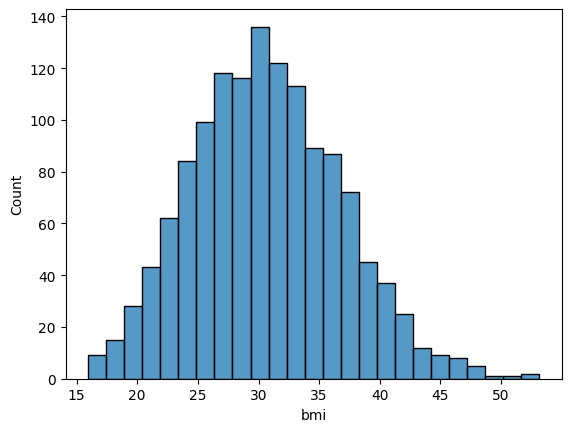

In [230]:
sns.histplot(df['bmi'])

In [231]:
df_clearned['bmi_categorg'] = pd.cut(
      df_clearned['bmi'],
    bins = [0,18.5,24.9,29.9,np.inf],
    labels = ['underweight','healthy','overweight','obese']
)

In [232]:
df_clearned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categorg
0,19,1,27.900,0,1,16884.92400,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,obese
2,28,0,33.000,3,0,4449.46200,False,True,False,obese
3,33,0,22.705,0,0,21984.47061,True,False,False,healthy
4,32,0,28.880,0,0,3866.85520,True,False,False,overweight


In [233]:
df_clearned = pd.get_dummies(df_clearned,columns =['bmi_categorg'],drop_first=True)

In [234]:
df_clearned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categorg_healthy,bmi_categorg_overweight,bmi_categorg_obese
0,19,1,27.900,0,1,16884.92400,False,False,True,False,True,False
1,18,0,33.770,1,0,1725.55230,False,True,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,True,False,False,False,True
3,33,0,22.705,0,0,21984.47061,True,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False,False,True,False


In [235]:
df_clearned = df_clearned.astype(int)

In [236]:
df_clearned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categorg_healthy,bmi_categorg_overweight,bmi_categorg_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [237]:
from sklearn.preprocessing import StandardScaler
col = ['age','bmi','children']
scaler = StandardScaler()
df_clearned[col]=scaler.fit_transform(df_clearned[col])

In [238]:
df_clearned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categorg_healthy,bmi_categorg_overweight,bmi_categorg_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [239]:
df_clearned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categorg_healthy,bmi_categorg_overweight,bmi_categorg_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [240]:
from scipy.stats import pearsonr


# List of features to check against target
selected_features = [
    'age',
    'bmi',
    'children',
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_categorg_healthy', # Corrected from bmi_category_Normal
    'bmi_categorg_overweight', # Corrected from bmi_category_Overweight
    'bmi_categorg_obese' # Corrected from bmi_category_Obese
]

# Calculate Pearson correlation with target
correlations = {
    feature: pearsonr(df_clearned[feature], df_clearned['charges'])[0]
    for feature in selected_features
}

correlations_df = pd.DataFrame(list(correlations.items()), columns=['Feature','Pearson Correlation'])
correlations_df = correlations_df.sort_values(by='Pearson Correlation',ascending=False)
display(correlations_df)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_categorg_obese,0.197660
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_categorg_healthy,-0.105656


In [241]:
df_clearned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_categorg_healthy', 'bmi_categorg_overweight',
       'bmi_categorg_obese'],
      dtype='object')

In [245]:
# List of categorical features for Chi-Square test
categorical_features = [
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_categorg_healthy',
    'bmi_categorg_overweight',
    'bmi_categorg_obese'
]


from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_clearned['charges_bin'] = pd.qcut(
    df_clearned['charges'],
    q=4,
    labels=False
)

chi2_results = {}

for col in categorical_features:

    contingency = pd.crosstab(
        df_clearned[col],
        df_clearned['charges_bin']
    )

    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    decision = (
        'Reject Null (Keep Feature)'
        if p_val < alpha
        else 'Accept Null (Drop Feature)'
    )

    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }




chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')

print(chi2_df)

                        chi2_statistic   p_value                    Decision
is_smoker                   848.219178       0.0  Reject Null (Keep Feature)
region_southeast             15.998167  0.001135  Reject Null (Keep Feature)
is_female                    10.258784   0.01649  Reject Null (Keep Feature)
bmi_categorg_obese            7.654464   0.05372  Accept Null (Drop Feature)
region_southwest              5.091893  0.165191  Accept Null (Drop Feature)
bmi_categorg_healthy          4.263673  0.234364  Accept Null (Drop Feature)
bmi_categorg_overweight       4.201575  0.240504  Accept Null (Drop Feature)
region_northwest               1.13424  0.768815  Accept Null (Drop Feature)


In [246]:
df_clearned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categorg_healthy,bmi_categorg_overweight,bmi_categorg_obese,charges_bin
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0,3
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0,3
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0,0


In [248]:
final_df = df_clearned[['age','is_female','bmi','children','is_smoker','charges','region_southeast']]

In [249]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast
0,-1.440418,1,-0.517949,-0.909234,1,16884,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1
2,-0.799350,0,0.462463,1.580143,0,4449,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0
...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0
1334,-1.511647,1,0.135659,-0.909234,0,2205,0
1335,-1.511647,1,0.952670,-0.909234,0,1629,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0
